# Kostic et al. 2023 Metrics 

## Functions for implementing and analysing metrics

### Spectral analysis metrics

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import expm
from tqdm import tqdm

from kooplearn._linalg import eigh_rank_reveal, spd_neg_pow, weighted_norm
from kooplearn.datasets import compute_prinz_potential_eig, make_prinz_potential
from kooplearn.kernel import KernelRidge


def operator_norm_error(true_operator: np.ndarray, estimated_operator: np.ndarray):
    r"""Operator norm error proxy for a Koopman estimator.

    Computes the operator norm discrepancy between the true action
    :math:`A_\pi S` and the estimated action :math:`S \widehat{G}`:

    .. math::

        \mathcal{E}(\widehat{G}) := \|A_\pi S - S \widehat{G}\|.

    Since "kooplearn" does not currently expose :math:`A_\pi` or the embedding
    operator :math:`S` explicitly, this function works with their actions on a
    common finite-dimensional representation. In practice, the caller should pass
    matrices or vectors representing the two quantities to be compared.
    """
    true_operator = np.asanyarray(true_operator)
    estimated_operator = np.asanyarray(estimated_operator)

    if true_operator.shape != estimated_operator.shape:
        raise ValueError(
            "true_operator and estimated_operator must have the same "
            f"shape, got {true_operator.shape} and "
            f"{estimated_operator.shape}."
        )

    diff = true_operator - estimated_operator
    if diff.ndim == 1:
        return float(np.linalg.norm(diff))
    return float(np.linalg.norm(diff, ord=2))


def metric_distortion(psi, C):
    r"""Empirical metric distortion :math:`\widehat\eta_i = \|\widehat\psi_i\|_{\mathcal H} /
    \sqrt{\langle \widehat C \widehat\psi_i, \widehat\psi_i\rangle}`.

    Parameters
    ----------
    psi : ndarray, shape (n,) or (n, k)
        Eigenfunction(s) evaluated at the *training* points. If 2D, each
        column is treated as a separate eigenfunction (see `weighted_norm`).
    C : ndarray, shape (n, n)
        Empirical (kernel-based) covariance, i.e. ``model.kernel_X / n_samples``.
    """
    psi = np.asarray(psi)
    n = C.shape[0]

    # ||psi||_H via the reproducing property: needs the *inverse* Gram, since
    # C = K_X / n is the Gram-based covariance, not the RKHS metric itself.
    C_inv = spd_neg_pow(C * n, exponent=-1.0)  # i.e. K_X^{-1}
    rkhs_norm = weighted_norm(psi, M=C_inv)

    # <C psi, psi> = (1/n)||psi(X)||_2^2, i.e. weighted_norm with M=None, squared, over n
    empirical_norm = weighted_norm(psi, M=None) / np.sqrt(n)

    with np.errstate(divide="ignore", invalid="ignore"):
        eta = rkhs_norm / empirical_norm
    eta = np.where(empirical_norm > 0, eta, np.nan)
    return eta if psi.ndim == 2 else float(eta)


def spectral_bias(eigenfunction, C, rho):
    r"""Empirical spectral bias :math:`\hat s_i = \widehat\eta_i \, \rho_{r+1}`."""
    eta = metric_distortion(eigenfunction, C)
    s_hat = eta * rho
    return float(s_hat), eta


def _top_sv(C, r):
    """(r+1)-st eigenvalue of a symmetric PSD matrix, via eigh_rank_reveal."""
    raw_vals, raw_vecs = np.linalg.eigh(np.asarray(C))
    _, top_vals, _ = eigh_rank_reveal(raw_vals, raw_vecs, rank=r + 1)
    if len(top_vals) <= r:
        return 0.0
    return float(top_vals[-1])


# --- truncation helpers ---
def pcr_truncation(C, r):
    r""":math:`\rho_{r+1}(\widehat G^{PCR}) = \sigma_{r+1}(\widehat C)`."""
    return _top_sv(C, r)


# kDMD uses the same (r+1)-st eigenvalue of the empirical covariance as PCR
kdmd_truncation = pcr_truncation


def rrr_truncation(C, T, r, cutoff=None):
    r""":math:`\rho_{r+1}(\widehat G^{RRR}) = \sigma_{r+1}(\widehat C^{-1/2}\widehat T)`."""
    C_inv_sqrt = spd_neg_pow(np.asarray(C), exponent=-0.5, cutoff=cutoff)
    A = C_inv_sqrt @ np.asarray(T)
    svals = np.linalg.svd(A, compute_uv=False)
    if r >= len(svals):
        return 0.0
    return float(svals[r])


# --- spectral gap (top-two magnitude eigenvalues) ---
def spectral_gap(eigenvalues):
    mags = np.sort(np.abs(eigenvalues))[::-1]
    return float(mags[0] - mags[1]) if len(mags) > 1 else np.nan


# --- spurious eigenvalues vs reference ---


def spurious_ref(est, ref, delta):
    dist = np.abs(est[:, None] - ref[None, :])
    return int(np.sum(dist.min(axis=1) > delta))


def spurious_residual(eigenvalues, psi_X_val, psi_Y_val, delta, relative=True):
    r"""Data-driven spurious-eigenpair check (see paper Appendix C, Remark 4).

    Flags eigenpairs that fail the empirical consistency check
    :math:`\hat\psi_i(y_j) \approx \hat\lambda_i \hat\psi_i(x_j)` on a
    held-out validation set.

    Parameters
    ----------
    eigenvalues : ndarray, shape (r,)
        Estimated eigenvalues, same order as columns of psi_X_val/psi_Y_val.
    psi_X_val : ndarray, shape (n_val, r)
        Eigenfunctions evaluated at validation inputs x_j.
    psi_Y_val : ndarray, shape (n_val, r)
        Same eigenfunctions evaluated at outputs y_j.
    delta : float
        Threshold on the residual score.
    relative : bool
        If True, normalize residual by ||psi_X_val||.

    Returns
    -------
    n_spurious : int
    scores : ndarray, shape (r,)
    """
    eigenvalues = np.asarray(eigenvalues)
    n_val = psi_X_val.shape[0]

    resid = psi_Y_val - psi_X_val * eigenvalues[None, :]
    resid_norm = weighted_norm(resid) / np.sqrt(n_val)

    if relative:
        base_norm = weighted_norm(psi_X_val) / np.sqrt(n_val)
        scores = np.full_like(resid_norm, np.nan, dtype=float)

        ok = np.isfinite(base_norm) & (base_norm > 0)
        scores[ok] = resid_norm[ok] / base_norm[ok]
    else:
        scores = resid_norm

    n_spurious = int(np.sum(scores > delta))
    return n_spurious, scores


# --- compilation function for analysing spectral metrics ---
def analyse_spectrum(modes_records, trials_records, out_prefix):
    modes_df = pd.DataFrame(modes_records).copy()
    trials_df = pd.DataFrame(trials_records).copy()

    if "spectral_gap" not in modes_df.columns:
        raise ValueError(
            f"modes_df is missing 'spectral_gap'. Columns: {modes_df.columns.tolist()}"
        )

    summary = modes_df.groupby(
        ["kernel", "kind", "method", "eigenfunction_id"], as_index=False
    ).agg(
        n=("spectral_bias", "size"),
        bias_mean=("spectral_bias", "mean"),
        bias_std=("spectral_bias", "std"),
        dist_mean=("metric_distortion", "mean"),
        trunc_mean=("truncation", "mean"),
        spurious_mean=("residual_spurious_score", "mean"),
        spurious_std=("residual_spurious_score", "std"),
    )

    rows = []
    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        gg = g[["spectral_bias", "spectral_gap"]].dropna()
        corr = gg["spectral_bias"].corr(gg["spectral_gap"]) if len(gg) > 1 else np.nan
        rows.append(
            {
                "kernel": kernel,
                "kind": kind,
                "method": method,
                "bias_gap_corr": corr,
            }
        )
    corr_df = pd.DataFrame(rows)

    summary.to_csv(f"{out_prefix}_summary.csv", index=False)
    modes_df.to_csv(f"{out_prefix}_metrics.csv", index=False)
    trials_df.to_csv(f"{out_prefix}_trials.csv", index=False)
    corr_df.to_csv(f"{out_prefix}_corr.csv", index=False)

    # ------------------------------------------------------------
    # Scatter diagnostics with compact, deduplicated legends
    # ------------------------------------------------------------

    def _short_kernel_label(x, max_chars=20):
        s = str(x)
        return s if len(s) <= max_chars else s[: max_chars - 1] + "…"

    def _build_group_label(kernel, kind, method, include_kernel=False):
        """
        Keep legend labels compact.
        By default, legend shows only kind + method.
        Set include_kernel=True only if the number of groups is small.
        """
        if include_kernel:
            return f"{_short_kernel_label(kernel)}, {kind} / {method}"
        return f"{kind} / {method}"

    def _dedup_legend(ax, title=None, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8):
        handles, labels = ax.get_legend_handles_labels()
        seen = {}
        for h, l in zip(handles, labels):
            if l and l != "_nolegend_" and l not in seen:
                seen[l] = h

        if seen:
            ax.legend(
                seen.values(),
                seen.keys(),
                frameon=False,
                fontsize=fontsize,
                title=title,
                loc=loc,
                bbox_to_anchor=bbox_to_anchor,
                borderaxespad=0.0,
            )

    # -----------------------------
    # Figure 1: spectral bias vs spectral gap
    # -----------------------------
    fig1, ax = plt.subplots(figsize=(8.5, 4.8))

    # Set this to True only when there are very few groups
    include_kernel_in_legend = True

    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        g = g[np.isfinite(g["spectral_bias"]) & np.isfinite(g["spectral_gap"])].copy()
        if g.empty:
            continue

        label = _build_group_label(
            kernel=kernel,
            kind=kind,
            method=method,
            include_kernel=include_kernel_in_legend,
        )

        ax.scatter(
            g["spectral_bias"],
            g["spectral_gap"],
            s=20,
            alpha=0.7,
            label=label,
        )

    ax.set_xlabel("Spectral bias")
    ax.set_ylabel("Spectral gap")
    ax.set_title("Spectral bias vs Spectral gap")
    ax.grid(alpha=0.25)

    _dedup_legend(
        ax,
        title="Condition / method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=8,
    )

    fig1.tight_layout()
    fig1.savefig(f"{out_prefix}_gap_scatter.png", dpi=200, bbox_inches="tight")
    plt.close(fig1)

    # -----------------------------
    # Figure 2: spectral bias vs residual spurious score
    # -----------------------------
    fig2, ax = plt.subplots(figsize=(8.5, 4.8))

    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        g = g[np.isfinite(g["spectral_bias"]) & np.isfinite(g["residual_spurious_score"])].copy()
        if g.empty:
            continue

        label = _build_group_label(
            kernel=kernel,
            kind=kind,
            method=method,
            include_kernel=include_kernel_in_legend,
        )

        ax.scatter(
            g["spectral_bias"],
            g["residual_spurious_score"],
            s=20,
            alpha=0.7,
            label=label,
        )

    ax.set_xlabel("Spectral bias")
    ax.set_ylabel("Residual spurious score")
    ax.set_title("Spectral bias vs Residual spurious score")
    ax.grid(alpha=0.25)

    _dedup_legend(
        ax,
        title="Condition / method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=8,
    )

    fig2.tight_layout()
    fig2.savefig(f"{out_prefix}_spurious_scatter.png", dpi=200, bbox_inches="tight")
    plt.close(fig2)

    return modes_df, trials_df, summary, corr_df, fig1, fig2


### Kernel scoring functions

In [7]:
from collections.abc import Mapping


def _normalise_series(s, method="zscore", larger_is_better=False):
    x = pd.to_numeric(s, errors="coerce").astype(float)
    if larger_is_better:
        x = -x

    x = x.replace([np.inf, -np.inf], np.nan)
    m = x.notna()

    out = pd.Series(np.nan, index=x.index, dtype=float)

    if m.sum() == 0:
        return out.fillna(0.0)

    vals = x[m].to_numpy(dtype=float)

    if method == "zscore":
        mu = np.nanmean(vals)
        sd = np.nanstd(vals)
        if not np.isfinite(sd) or sd == 0:
            out.loc[m] = 0.0
        else:
            out.loc[m] = (vals - mu) / sd

    elif method == "minmax":
        lo = np.nanmin(vals)
        hi = np.nanmax(vals)
        if not np.isfinite(hi - lo) or hi == lo:
            out.loc[m] = 0.0
        else:
            out.loc[m] = (vals - lo) / (hi - lo)

    elif method == "rank":
        out.loc[m] = pd.Series(vals).rank(method="average").to_numpy(dtype=float)
        out.loc[m] = out.loc[m].max() - out.loc[m]
        denom = out.loc[m].max()
        if denom > 0:
            out.loc[m] = out.loc[m] / denom
        else:
            out.loc[m] = 0.0
    else:
        raise ValueError(f"Unknown normalise method: {method}")

    return out.fillna(0.0)


def kernel_spectral_score(
    summary,
    trials_df=None,
    *,
    group_cols=("kernel", "kind", "method"),
    selected_modes=None,
    mode_weights=None,
    normalise="zscore",
    metric_weights=None,
    hard_constraints=None,
    use_trial_metrics=True,
):
    """
    Second-stage kernel scoring built on top of analyse_spectrum outputs.

    Parameters
    ----------
    summary : pd.DataFrame
        Output `summary` from analyse_spectrum(...), with columns:
        ['kernel', 'kind', 'method', 'eigenfunction_id',
         'n', 'bias_mean', 'bias_std', 'dist_mean',
         'trunc_mean', 'spurious_mean', 'spurious_std']
    trials_df : pd.DataFrame or None
        Output `trials_df` from analyse_spectrum(...), with columns:
        ['kind', 'method', 'trial', 'spurious_ref_count',
         'spurious_residual_count', 'spectral_gap', 'rank']
        Optional, but recommended.
    group_cols : tuple[str, ...]
        Kernel identity columns.
    selected_modes : sequence[int] or None
        Which eigenfunction_id values to use. None means all.
    mode_weights : Mapping[int, float] or None
        Per-mode weights. If None, uses equal weights over selected modes.
    normalise : {"zscore", "minmax", "rank"}
        Normalisation used across candidate kernels.
    metric_weights : Mapping[str, float] or None
        Weights for the normalised metrics.
    hard_constraints : Mapping[str, float] or None
        Optional admissibility thresholds, e.g.
        {"max_spurious_ref_count": 2, "max_dist_mean": 20, "min_spectral_gap": 0.02}
    use_trial_metrics : bool
        If True and trials_df is provided, include trial-level aggregates.

    Returns
    -------
    mode_agg_df : pd.DataFrame
        Per-kernel aggregated raw metrics before normalisation.
    kernel_scores_df : pd.DataFrame
        Per-kernel normalised metrics, admissibility flags, composite score, rank.
    """

    summary = summary.copy()

    if selected_modes is not None:
        summary = summary[summary["eigenfunction_id"].isin(selected_modes)].copy()

    if summary.empty:
        raise ValueError("No rows remain in summary after filtering selected_modes.")

    if mode_weights is None:
        present_modes = sorted(summary["eigenfunction_id"].unique())
        mode_weights = {m: 1.0 for m in present_modes}
    elif isinstance(mode_weights, Mapping):
        mode_weights = dict(mode_weights)
    else:
        mode_weights = {m: w for m, w in mode_weights}

    summary["mode_weight"] = summary["eigenfunction_id"].map(mode_weights).fillna(0.0)
    if (summary["mode_weight"] < 0).any():
        raise ValueError("mode_weights must be nonnegative.")

    def _wavg(g, col):
        w = g["mode_weight"].to_numpy(dtype=float)
        x = g[col].to_numpy(dtype=float)
        if np.all(w == 0) or np.all(~np.isfinite(x)):
            return np.nan
        return float(np.average(x, weights=w))

    mode_agg_df = (
        summary.groupby(list(group_cols), as_index=False)
        .apply(
            lambda g: pd.Series(
                {
                    "n_modes_used": int(g["eigenfunction_id"].nunique()),
                    "weight_sum": float(g["mode_weight"].sum()),
                    "agg_bias_mean": _wavg(g, "bias_mean"),
                    "agg_bias_std": _wavg(g, "bias_std"),
                    "agg_dist_mean": _wavg(g, "dist_mean"),
                    "agg_trunc_mean": _wavg(g, "trunc_mean"),
                    "agg_spurious_mean": _wavg(g, "spurious_mean"),
                    "agg_spurious_std": _wavg(g, "spurious_std"),
                }
            )
        )
        .reset_index(drop=True)
    )

    if use_trial_metrics and trials_df is not None:
        trials_df = trials_df.copy()
        trial_group_cols = [c for c in group_cols if c in trials_df.columns]

        trial_agg = trials_df.groupby(trial_group_cols, as_index=False).agg(
            mean_spurious_ref_count=("spurious_ref_count", "mean"),
            mean_spurious_residual_count=("spurious_residual_count", "mean"),
            mean_spectral_gap=("spectral_gap", "mean"),
            std_spectral_gap=("spectral_gap", "std"),
            mean_rank=("rank", "mean"),
        )

        mode_agg_df = mode_agg_df.merge(trial_agg, on=trial_group_cols, how="left")

    if metric_weights is None:
        metric_weights = {
            "agg_bias_mean": 1.0,
            "agg_dist_mean": 1.0,
            "agg_spurious_mean": 1.0,
            "agg_trunc_mean": 0.5,
            "agg_bias_std": 0.25,
            "agg_spurious_std": 0.25,
            "mean_spurious_ref_count": 0.75,
            "mean_spurious_residual_count": 0.75,
            "mean_spectral_gap": 0.75,
            "std_spectral_gap": 0.25,
        }

    larger_is_better = {"mean_spectral_gap": True}

    kernel_scores_df = mode_agg_df.copy()

    used_metrics = []
    for metric, weight in metric_weights.items():
        if metric not in kernel_scores_df.columns or weight == 0:
            continue
        kernel_scores_df[f"{metric}_norm"] = _normalise_series(
            kernel_scores_df[metric],
            method=normalise,
            larger_is_better=larger_is_better.get(metric, False),
        )
        used_metrics.append(metric)

    score = np.zeros(len(kernel_scores_df), dtype=float)
    for metric, weight in metric_weights.items():
        norm_col = f"{metric}_norm"
        if norm_col in kernel_scores_df.columns and weight != 0:
            score += weight * kernel_scores_df[norm_col].to_numpy(dtype=float)

    kernel_scores_df["composite_score"] = score
    kernel_scores_df["used_metrics"] = ", ".join(used_metrics)

    kernel_scores_df["admissible"] = True
    kernel_scores_df["constraint_violations"] = ""

    if hard_constraints:
        admissible = np.ones(len(kernel_scores_df), dtype=bool)
        viol = [[] for _ in range(len(kernel_scores_df))]

        def _mark(mask, label):
            nonlocal admissible
            if mask is not None:
                admissible &= ~mask
                for i in np.where(mask)[0]:
                    viol[i].append(label)

        if (
            "max_spurious_ref_count" in hard_constraints
            and "mean_spurious_ref_count" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spurious_ref_count"]
                > hard_constraints["max_spurious_ref_count"],
                "spurious_ref",
            )

        if (
            "max_spurious_residual_count" in hard_constraints
            and "mean_spurious_residual_count" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spurious_residual_count"]
                > hard_constraints["max_spurious_residual_count"],
                "spurious_residual",
            )

        if "max_dist_mean" in hard_constraints:
            _mark(
                kernel_scores_df["agg_dist_mean"] > hard_constraints["max_dist_mean"], "distortion"
            )

        if "max_bias_mean" in hard_constraints:
            _mark(kernel_scores_df["agg_bias_mean"] > hard_constraints["max_bias_mean"], "bias")

        if "max_trunc_mean" in hard_constraints:
            _mark(
                kernel_scores_df["agg_trunc_mean"] > hard_constraints["max_trunc_mean"],
                "truncation",
            )

        if (
            "min_spectral_gap" in hard_constraints
            and "mean_spectral_gap" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spectral_gap"] < hard_constraints["min_spectral_gap"], "gap"
            )

        kernel_scores_df["admissible"] = admissible
        kernel_scores_df["constraint_violations"] = [",".join(v) for v in viol]

    kernel_scores_df = kernel_scores_df.sort_values(
        ["admissible", "composite_score"],
        ascending=[False, True],
    ).reset_index(drop=True)

    kernel_scores_df["rank"] = np.arange(1, len(kernel_scores_df) + 1)

    return mode_agg_df, kernel_scores_df


### Plotting function

In [8]:
def plot_kernel_rankings(
    kernel_scores,
    trials_df=None,
    prefix="Kernel ranking",
    score_col="composite_score",
    kernel_col="kernel",
    method_col="method",
    facet_col="kind",
    rank_col="rank",
    gap_col_candidates=("gap_mean", "spectral_gap", "gap"),
    figsize_scale=(6, 4),
    annotate_bars=True,
    annotate_scatter=False,
    max_label_chars=28,
    sort_facets=True,
    sort_methods=True,
    sort_kernels_by_score=True,
    color_by_facet=True,
):
    """
    General plotting utility for kernel ranking outputs.

    Parameters
    ----------
    kernel_scores : pd.DataFrame
        Must contain at least kernel_col, method_col, score_col.
        May also contain facet_col, rank_col, and a gap column.
    trials_df : pd.DataFrame or None
        Optional trial-level dataframe used to compute mean spectral gap
        if kernel_scores does not already contain one.
    prefix : str
        Figure title prefix.
    score_col, kernel_col, method_col, facet_col, rank_col : str
        Column names to use.
    gap_col_candidates : tuple[str]
        Candidate names for gap columns.
    figsize_scale : tuple[float, float]
        Base width, height per panel.
    annotate_bars : bool
        Add rank labels above bars.
    annotate_scatter : bool
        Add kernel labels on scatter points.
    max_label_chars : int
        Maximum kernel label length before truncation.
    sort_facets, sort_methods, sort_kernels_by_score : bool
        Sorting behavior.
    color_by_facet : bool
        In scatter plot, color points by facet values. If False, use one color.
    """

    plot_df = kernel_scores.copy()

    # ---------- Validation ----------
    required = [kernel_col, method_col, score_col]
    missing = [c for c in required if c not in plot_df.columns]
    if missing:
        raise ValueError(f"kernel_scores is missing required columns: {missing}")

    # ---------- Ensure facet column exists ----------
    if facet_col is None or facet_col not in plot_df.columns:
        facet_col = "_facet"
        plot_df[facet_col] = "All"

    # ---------- Compute rank if missing ----------
    if rank_col not in plot_df.columns:
        group_cols = [c for c in [facet_col, method_col] if c in plot_df.columns]
        plot_df[rank_col] = (
            plot_df.groupby(group_cols)[score_col].rank(method="first", ascending=True).astype(int)
        )

    # ---------- Resolve / attach gap column ----------
    resolved_gap_col = None
    for c in gap_col_candidates:
        if c in plot_df.columns:
            resolved_gap_col = c
            break

    if resolved_gap_col is None and trials_df is not None:
        trial_df = trials_df.copy()

        if facet_col not in trial_df.columns:
            trial_df[facet_col] = "All"

        trial_gap_col = None
        for c in gap_col_candidates:
            if c in trial_df.columns:
                trial_gap_col = c
                break

        if trial_gap_col is not None:
            candidate_group_cols = [kernel_col, facet_col, method_col]
            group_cols = [c for c in candidate_group_cols if c in trial_df.columns]
            gap_df = (
                trial_df.groupby(group_cols, as_index=False)[trial_gap_col]
                .mean()
                .rename(columns={trial_gap_col: "gap_mean"})
            )

            merge_cols = [
                c for c in candidate_group_cols if c in plot_df.columns and c in gap_df.columns
            ]
            plot_df = plot_df.merge(gap_df, on=merge_cols, how="left")
            resolved_gap_col = "gap_mean"

    # ---------- Label helpers ----------
    def short_label(x, max_chars=max_label_chars):
        s = str(x)
        return s if len(s) <= max_chars else s[: max_chars - 1] + "…"

    def _dedup_legend(ax, title=None, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8):
        handles, labels = ax.get_legend_handles_labels()
        seen = {}
        for h, l in zip(handles, labels):
            if l and l != "_nolegend_" and l not in seen:
                seen[l] = h

        if seen:
            ax.legend(
                seen.values(),
                seen.keys(),
                frameon=False,
                fontsize=fontsize,
                title=title,
                loc=loc,
                bbox_to_anchor=bbox_to_anchor,
                borderaxespad=0.0,
            )

    plot_df["_kernel_label"] = plot_df[kernel_col].map(short_label)

    # ---------- Ordering ----------
    facets = list(plot_df[facet_col].dropna().unique())
    methods = list(plot_df[method_col].dropna().unique())

    if sort_facets:
        try:
            facets = sorted(facets)
        except Exception:
            pass

    if sort_methods:
        try:
            methods = sorted(methods)
        except Exception:
            pass

    # ---------- Figure 1: bar rankings ----------
    fig1, axes = plt.subplots(
        len(facets),
        len(methods),
        figsize=(figsize_scale[0] * len(methods), figsize_scale[1] * len(facets)),
        squeeze=False,
    )

    for i, facet_val in enumerate(facets):
        for j, method in enumerate(methods):
            ax = axes[i, j]
            g = plot_df[(plot_df[facet_col] == facet_val) & (plot_df[method_col] == method)].copy()
            g = g[np.isfinite(g[score_col])].copy()

            if sort_kernels_by_score:
                g = g.sort_values(score_col, ascending=True)
            elif rank_col in g.columns:
                g = g.sort_values(rank_col, ascending=True)

            if g.empty:
                ax.set_visible(False)
                continue

            x = np.arange(len(g))
            ax.bar(x, g[score_col], color="#6ebdc2", alpha=0.85)
            ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(g["_kernel_label"], rotation=45, ha="right")
            ax.set_ylabel("Composite score")
            ax.set_title(f"{prefix}: {facet_col}={facet_val} / {method}")
            ax.grid(axis="y", alpha=0.25)

            if annotate_bars and rank_col in g.columns:
                for xi, (_, row) in zip(x, g.iterrows()):
                    ax.annotate(
                        f"#{int(row[rank_col])}",
                        xy=(xi, row[score_col]),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        clip_on=True,
                    )

    fig1.subplots_adjust(bottom=0.25, hspace=0.35, wspace=0.25)
    fig1.savefig(f"{prefix}_ranking_score.png", dpi=200)
    plt.show()

    # ---------- Figure 2: score vs gap ----------
    if resolved_gap_col is not None and resolved_gap_col in plot_df.columns:
        fig2, axes = plt.subplots(
            1,
            len(methods),
            figsize=(figsize_scale[0] * len(methods), figsize_scale[1]),
            squeeze=False,
        )

        cmap = plt.get_cmap("tab10")
        facet_to_color = {facet: cmap(k % 10) for k, facet in enumerate(facets)}

        for j, method in enumerate(methods):
            ax = axes[0, j]

            for facet_val in facets:
                g = plot_df[
                    (plot_df[method_col] == method) & (plot_df[facet_col] == facet_val)
                ].copy()
                g = g[np.isfinite(g[score_col]) & np.isfinite(g[resolved_gap_col])].copy()

                if g.empty or resolved_gap_col not in g.columns:
                    continue

                color = facet_to_color[facet_val] if color_by_facet else None

                ax.scatter(
                    g[resolved_gap_col],
                    g[score_col],
                    s=60,
                    alpha=0.8,
                    label=str(facet_val),
                    color=color,
                )

                if annotate_scatter:
                    for _, row in g.iterrows():
                        ax.annotate(
                            row["_kernel_label"],
                            (row[resolved_gap_col], row[score_col]),
                            xytext=(4, 4),
                            textcoords="offset points",
                            fontsize=8,
                        )

            ax.set_xlabel("Mean spectral gap")
            ax.set_ylabel("Composite score")
            ax.set_title(f"{prefix} score vs gap: {method}")
            ax.grid(alpha=0.25)

            _dedup_legend(
                ax,
                title="Condition / method",
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                fontsize=8,
            )
        fig2.savefig(f"{prefix}_score_gap.png", dpi=200, bbox_inches="tight")
        plt.show()
    else:
        print("No spectral gap column found or derivable; skipping score-vs-gap scatter.")

    return plot_df


In [9]:
# Hermite kernel construction a la Kostic et al. 2023
import re


def hermite_features(x, M):
    """Normalized probabilists' Hermite functions f_n = He_n/sqrt(n!),
    via sqrt(n) f_n = x f_{n-1} - sqrt(n-1) f_{n-2}. No factorial, no hermeval."""
    x = np.asarray(x).reshape(-1)
    f = np.empty((x.shape[0], M))
    f[:, 0] = 1.0
    if M > 1:
        f[:, 1] = x
    for n in range(2, M):
        f[:, n] = (x * f[:, n - 1] - np.sqrt(n - 1) * f[:, n - 2]) / np.sqrt(n)
    return f


def hermite_kernel(kind, r, M):
    w = make_weights(kind, r, M)
    cache = {}

    def get_features(x):
        key = np.asarray(x).ravel().tobytes()
        feats = cache.get(key)
        if feats is None:
            feats = hermite_features(x, M)[0]
            cache[key] = feats
        return feats

    def kernel(x, y):
        fx, fy = get_features(x), get_features(y)
        return float(np.sum(w * fx * fy))

    return kernel


def kernel_permutation(kind, r, M):
    pi = np.arange(M)
    if kind == "good":
        return pi
    if kind == "bad":
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r for bad kernel, got M={M}, r={r}")
        pi2 = pi.copy()
        a, b = np.arange(r), np.arange(r, 2 * r)
        pi2[a], pi2[b] = b[::-1], a[::-1]
        return pi2
    if kind == "ugly":
        return pi[::-1]
    raise ValueError(kind)


def make_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    nu = 1.0 if kind == "good" else (1.0 / (r**2) if kind == "bad" else r**2)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


def extract_kvar(kernel_name):
    m = re.search(r"hermite(([0-9.eE+-]+))", str(kernel_name))
    return m.group(1) if m else str(kernel_name)


## RQ1

### Overdamped Langevin Spectral Analysis

In [5]:
import itertools

x = np.linspace(-2, 2, 2048 + 1)
gamma = 1.0
sigma = 2.0
dt = 1e-4
subsample = 100
n_train = 2000
n_val = 500
n_trials = 10
n_show = 3
# training simulation:
n_steps_train = n_train * subsample
# validation simulation:
n_steps_val = n_val * subsample
M = 10
n_components = 5
r = n_components

trials_records = []
modes_records = []
for method, reduced_rank, kvar in itertools.product(
    ["Principal Components (kDMD)", "Reduced Rank"], [False, True], ["good", "bad", "ugly"]
):
    for trial in tqdm(range(n_trials), desc=f"{method}/{kvar}"):
        train_seed = 10_000 + trial
        val_seed = 20_000 + trial
        data = make_prinz_potential(
            X0=0, n_steps=n_steps_train, gamma=gamma, sigma=sigma, random_state=train_seed
        ).iloc[::subsample][:n_train]

        data_val = make_prinz_potential(
            X0=0, n_steps=n_steps_val, gamma=gamma, sigma=sigma, random_state=val_seed
        ).iloc[::subsample][:n_val]

        X_val = data_val.iloc[:-1].values
        Y_val = data_val.iloc[1:].values

        vals_ref = compute_prinz_potential_eig(gamma, sigma, dt, num_components=5)

        kernel = hermite_kernel(kvar, r, M)
        model = KernelRidge(
            n_components=n_components,
            reduced_rank=reduced_rank,
            kernel=kernel,
            alpha=0,
            random_state=trial,  # estimator-internal randomness separate from data draw
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)

        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )
        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            rrr_truncation(C, T, fit_rank)
            if method == "Reduced Rank"
            else pcr_truncation(C, fit_rank)
        )
        trials_records.append(
            {
                "kind": "N/A",
                "method": method,
                "trial": trial,
                "data_seed": train_seed,
                "spurious_ref_count": int(n_spur),
                "spurious_residual_count": int(n_residual),
                "spectral_gap": gap,
                "rank": fit_rank,
            }
        )

        modes = model.dynamical_modes(data)
        n_modes = modes.n_modes
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records.append(
                {
                    "kind": "N/A",
                    "kernel": f"hermite({kvar})",
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": gap,
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                }
            )

modes_df_lg, trials_df_lg, summary_lg, corr_df_lg, fig1_lg, fig2_lg = analyse_spectrum(
    modes_records, trials_records, out_prefix="langevin_herm"
)


Principal Components (kDMD)/ugly:   0%|          | 0/10 [00:00<?, ?it/s]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 4 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 5.318e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Principal Components (kDMD)/ugly:  10%|█         | 1/10 [2:14:23<20:09:27, 8063.01s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 4 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 4.982e-15.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Principal Components (kDMD)/ugly:  20%|██        | 2/10 [3:55:57<15:20:39, 6904.91s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_ut

In [6]:
baseline_metric_weights = {
    "agg_bias_mean": 1.0,
    "agg_dist_mean": 1.0,
    "agg_spurious_mean": 1.00,  # was 0.75
    "agg_trunc_mean": 0.5,
    "agg_bias_std": 0.25,
    "agg_spurious_std": 0.25,
    "mean_spurious_ref_count": 0.5,
    "mean_spurious_residual_count": 1.00,  # was 0.75
    "mean_spectral_gap": 0.5,
}

hard_constraints = {
    "max_spurious_ref_count": 4,
    "max_spurious_residual_count": 5,
}

selected_modes = [1, 2, 3]
mode_weights = {1: 0.5, 2: 0.3, 3: 0.2}

# 1) Recompute baseline ranking with stronger spurious penalties
mode_agg_lg, kernel_scores_lg = kernel_spectral_score(
    summary_lg,
    trials_df=trials_df_lg,
    group_cols=("kernel", "method"),
    selected_modes=selected_modes,
    mode_weights=mode_weights,
    normalise="zscore",
    metric_weights=baseline_metric_weights,
    hard_constraints=hard_constraints,
)

mode_agg_lg.to_csv("langevin_herm_modes.csv", index=False)
kernel_scores_lg.to_csv("langevin_herm_scores.csv", index=False)

lg_scores_sorted = kernel_scores_lg.sort_values(
    ["admissible", "rank"], ascending=[False, True]
).reset_index(drop=True)

lg_scores_sorted.to_csv("langevin_herm_ranking.csv", index=False)


# 2) Compact sensitivity study around the new baseline
def run_weight_sensitivity(
    summary,
    trials_df,
    *,
    base_weights,
    vary_metrics=("agg_spurious_mean", "mean_spurious_residual_count"),
    scales=(0.8, 1.0, 1.2),
    selected_modes=(1, 2, 3),
    mode_weights=None,
    normalise="zscore",
    hard_constraints=None,
    top_k=5,
):
    rows = []
    top_rows = []

    for metric in vary_metrics:
        for scale in scales:
            w = dict(base_weights)
            w[metric] = base_weights[metric] * scale

            _, scores = kernel_spectral_score(
                summary,
                trials_df=trials_df,
                group_cols=("kernel", "kind", "method"),
                selected_modes=list(selected_modes),
                mode_weights=mode_weights,
                normalise=normalise,
                metric_weights=w,
                hard_constraints=hard_constraints,
            )

            scores_sorted = scores.sort_values(
                ["admissible", "rank"], ascending=[False, True]
            ).reset_index(drop=True)
            top = scores_sorted.head(top_k).copy()

            best_row = top.iloc[0]
            rows.append(
                {
                    "varied_metric": metric,
                    "scale": scale,
                    "best_kernel": best_row["kernel"],
                    "best_kind": best_row["kind"],
                    "best_method": best_row["method"],
                    "best_score": best_row["composite_score"],
                    "best_rank": best_row["rank"],
                    "best_admissible": best_row["admissible"],
                    "top5_signature": " | ".join(
                        f"{r['kernel']} / {r['method']} (r{int(r['rank'])})"
                        for _, r in top.iterrows()
                    ),
                }
            )

            top["varied_metric"] = metric
            top["scale"] = scale
            top_rows.append(top)

    summary_df = pd.DataFrame(rows).sort_values(["varied_metric", "scale"]).reset_index(drop=True)
    top_df = pd.concat(top_rows, ignore_index=True)
    return summary_df, top_df


sensitivity_summary_lg, sensitivity_top_lg = run_weight_sensitivity(
    summary_lg,
    trials_df_lg,
    base_weights=baseline_metric_weights,
    vary_metrics=("agg_spurious_mean", "mean_spurious_residual_count"),
    scales=(0.8, 1.0, 1.2, 1.4),
    selected_modes=selected_modes,
    mode_weights=mode_weights,
    normalise="zscore",
    hard_constraints=hard_constraints,
    top_k=5,
)

sensitivity_summary_lg.to_csv("langevin_herm_sensitivity.csv", index=False)

display(
    sensitivity_top_lg[
        [
            "varied_metric",
            "scale",
            "kernel",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
        ]
    ].sort_values(["varied_metric", "scale", "rank"])
)

drop_tests = []
for dropped_metric in ["agg_spurious_mean", "mean_spurious_residual_count"]:
    w = dict(baseline_metric_weights)
    w[dropped_metric] = 0.0

    _, scores = kernel_spectral_score(
        summary_lg,
        trials_df=trials_df_lg,
        group_cols=("kernel", "method"),
        selected_modes=selected_modes,
        mode_weights=mode_weights,
        normalise="zscore",
        metric_weights=w,
        hard_constraints=hard_constraints,
    )

    best = scores.sort_values(["admissible", "rank"], ascending=[False, True]).iloc[0]
    drop_tests.append(
        {
            "dropped_metric": dropped_metric,
            "best_kernel": best["kernel"],
            "best_method": best["method"],
            "best_score": best["composite_score"],
            "best_rank": best["rank"],
        }
    )

drop_tests_herm = pd.DataFrame(drop_tests)
drop_tests_herm.to_csv("herm_drop_tests.csv", index=False)
display(drop_tests_herm)


,varied_metric,scale,kernel,method,composite_score,rank,admissible,agg_bias_mean,agg_dist_mean,agg_spurious_mean,mean_spurious_residual_count,mean_spectral_gap
0,agg_spurious_mean,0.8,hermite(bad),Principal Components (kDMD),-1.125518,1,True,1.348140e-02,310.595206,0.341627,3.283333,0.912592
1,agg_spurious_mean,0.8,hermite(ugly),Principal Components (kDMD),-0.023576,2,True,0.000000e+00,3.265033,1.057479,3.283333,0.912592
2,agg_spurious_mean,0.8,hermite(ugly),Reduced Rank,-0.023576,3,True,3.017958e-15,3.265033,1.057479,3.283333,0.912592
3,agg_spurious_mean,0.8,hermite(good),Principal Components (kDMD),0.726808,4,True,1.616652e-04,722.406961,0.408325,3.283333,0.912592
4,agg_spurious_mean,0.8,hermite(bad),Reduced Rank,1.286365,5,True,1.777415e-01,310.595206,0.341627,3.283333,0.912592
5,agg_spurious_mean,1.0,hermite(bad),Principal Components (kDMD),-1.287092,1,True,1.348140e-02,310.595206,0.341627,3.283333,0.912592
6,agg_spurious_mean,1.0,hermite(ugly),Principal Components (kDMD),0.258259,2,True,0.000000e+00,3.265033,1.057479,3.283333,0.912592
7,agg_spurious_mean,1.0,hermite(ugly),Reduced Rank,0.258259,3,True,3.017958e-15,3.265033,1.057479,3.283333,0.912592
8,agg_spurious_mean,1.0,hermite(good),Principal Components (kDMD),0.606547,4,True,1.616652e-04,722.406961,0.408325,3.283333,0.912592
9,agg_spurious_mean,1.0,hermite(bad),Reduced Rank,1.124791,5,True,1.777415e-01,310.595206,0.341627,3.283333,0.912592


,dropped_metric,best_kernel,best_method,best_score,best_rank
0,agg_spurious_mean,hermite(ugly),Principal Components (kDMD),-1.150917,1
1,mean_spurious_residual_count,hermite(bad),Principal Components (kDMD),-2.287092,1


In [6]:
lg_scores_sorted = pd.read_csv("langevin_herm_ranking.csv")


plot_df = lg_scores_sorted.copy()

top = (
    plot_df.sort_values("composite_score", ascending=True)
    .groupby(["method"], as_index=False)
    .head(15)
    .copy()
)

top = top.sort_values(["method"]).reset_index(drop=True)

method_colors = {
    "Principal Components (kDMD)": "#59CF82",
    "Reduced Rank": "#F7B577",
}
method_markers = {
    "Principal Components (kDMD)": "o",
    "Reduced Rank": "s",
}


top["kvar"] = top["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(9, 5.5))

for method, g in top.groupby("method"):
    ax.plot(
        g["kvar"],
        g["composite_score"],
        color=method_colors.get(method, "tab:gray"),
        linewidth=1.5,
        alpha=0.8,
    )

    ax.scatter(
        g["kvar"],
        g["composite_score"],
        color=method_colors.get(method, "tab:gray"),
        marker=method_markers.get(method, "o"),
        s=60,
        alpha=0.9,
        label=method,
    )

ax.set_xlabel("Hermite kind")
ax.set_ylabel("Composite score")
ax.tick_params(axis="x", labelrotation=90, labelsize=7)
ax.legend(frameon=False, title="Method")

fig.savefig("langevin_herm_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

fig4, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
plot_df["kvar"] = plot_df["kernel"].map(extract_kvar)

for ax, method in zip(axes, plot_df["method"].drop_duplicates()):
    sub = plot_df[plot_df["method"] == method].sort_values("rank").reset_index(drop=True)
    x = np.arange(len(sub))
    ax.bar(x, sub["composite_score"], color="#D667BD", width=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["kvar"], rotation=90, ha="right", fontsize=7)
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Composite score")

fig4.suptitle("Langevin Hermite kernel ranking by method")
fig4.savefig("langevin_herm_ranking_method.png", dpi=200, bbox_inches="tight")
plt.close(fig4)

print("Saved langevin hermite outputs.")


Saved langevin hermite outputs.


### OU spectral analysis

In [ ]:
import itertools

import numpy as np

x_grid = np.linspace(-4, 4, 1025)[:, None]  # for later plotting eigenfunctions, if wanted
gamma = 1.0
dt = 1e-4
subsample = 100
n_train = 2000
n_val = 500
n_trials = 10
n_show = 3
M = 10
n_components = 3
r = n_components  # target rank for the good/bad/ugly permutation construction
n_burn = 200
# if one trajectory: n_steps = (n_train + n_val + n_burn) * subsample


def simulate_ou(n_steps, gamma, dt, random_state, x0=0.0):
    """AR(1) sampled from the exact OU transition at physical step size dt."""
    rng = np.random.default_rng(random_state)
    a = np.exp(-gamma * dt)
    b = np.sqrt(1.0 - a**2)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


def compute_ou_eig(gamma, lag, num_components):
    n = np.arange(num_components)
    return np.exp(-n * gamma * lag)


n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

lag = dt * subsample  # consistent with how `data` was actually generated
vals_ref = compute_ou_eig(gamma, lag, num_components=n_components)

trials_records = []
modes_records = []
for method, reduced_rank, kvar in itertools.product(
    ["PCR", "Reduced Rank"], [False, True], ["good", "bad", "ugly"]
):
    for trial in tqdm(range(n_trials), desc=f"{method}/{kvar}"):
        # --- resample a fresh trajectory for THIS trial ---
        data_seed = 10_000 + trial  # distinct from val seed and from model seed
        val_seed = 20_000 + trial

        data = simulate_ou(
            n_steps=n_steps_train,
            gamma=gamma,
            dt=dt,
            random_state=data_seed,
            x0=0.0,
        ).iloc[::subsample][:n_train]

        data_val = simulate_ou(
            n_steps=n_steps_val,
            gamma=gamma,
            dt=dt,
            random_state=val_seed,
            x0=0.0,
        )
        data_val = data_val.iloc[::subsample].reset_index(drop=True)[:n_val]

        X_val = data_val.iloc[:-1].values
        Y_val = data_val.iloc[1:].values
        # --- end resampling ---

        kernel = hermite_kernel(kvar, r, M)
        model = KernelRidge(
            n_components=n_components,
            reduced_rank=reduced_rank,
            kernel=kernel,
            alpha=0,
            random_state=trial,  # estimator-internal randomness separate from data draw
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)

        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )
        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            rrr_truncation(C, T, fit_rank)
            if method == "Reduced Rank"
            else pcr_truncation(C, fit_rank)
        )
        trials_records.append(
            {
                "kind": "N/A",
                "method": method,
                "trial": trial,
                "data_seed": data_seed,
                "spurious_ref_count": int(n_spur),
                "spurious_residual_count": int(n_residual),
                "spectral_gap": gap,
                "rank": fit_rank,
            }
        )

        modes = model.dynamical_modes(data)
        n_modes = modes.n_modes
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records.append(
                {
                    "kind": "N/A",
                    "kernel": f"hermite({kvar})",
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": gap,
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                }
            )

modes_df_ou, trials_df_ou, summary_ou, corr_df_ou, fig1_ou, fig2_ou = analyse_spectrum(
    modes_records, trials_records, "ou_herm"
)


PCR/ugly:  80%|████████  | 8/10 [1:09:43<15:30, 465.39s/it]   /Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 3 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 5.846e-06.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
PCR/ugly:  90%|█████████ | 9/10 [1:10:41<05:38, 338.19s/it]

In [8]:
def validate_ou(kernel_scores_df, *, method_order=None):
    """
    Summarise whether the composite score respects the expected OU ordering:
    good < bad < ugly, within each method.

    Returns
    -------
    validation_df : pd.DataFrame
        One row per method with ordering diagnostics.
    """
    df = kernel_scores_df.copy()

    if "kernel" not in df.columns or "method" not in df.columns:
        raise ValueError("kernel_scores_df must contain 'kernel' and 'method' columns.")

    df["kvar"] = df["kernel"].map(extract_kvar)

    rows = []
    for method, g in df.groupby("method"):
        gg = g.set_index("kvar")

        needed = ["good", "bad", "ugly"]
        has_all = all(k in gg.index for k in needed)

        row = {"method": method, "has_all_kinds": has_all}
        if has_all:
            score_good = float(gg.loc["good", "composite_score"])
            score_bad = float(gg.loc["bad", "composite_score"])
            score_ugly = float(gg.loc["ugly", "composite_score"])

            rank_good = int(gg.loc["good", "rank"])
            rank_bad = int(gg.loc["bad", "rank"])
            rank_ugly = int(gg.loc["ugly", "rank"])

            row.update(
                {
                    "score_good": score_good,
                    "score_bad": score_bad,
                    "score_ugly": score_ugly,
                    "rank_good": rank_good,
                    "rank_bad": rank_bad,
                    "rank_ugly": rank_ugly,
                    "good_lt_bad": score_good < score_bad,
                    "bad_lt_ugly": score_bad < score_ugly,
                    "good_lt_ugly": score_good < score_ugly,
                    "full_order_correct": (score_good < score_bad) and (score_bad < score_ugly),
                }
            )
        rows.append(row)

    validation_df = pd.DataFrame(rows)
    if method_order is not None and "method" in validation_df.columns:
        validation_df["method"] = pd.Categorical(
            validation_df["method"], categories=method_order, ordered=True
        )
        validation_df = validation_df.sort_values("method").reset_index(drop=True)

    return validation_df


# Frozen Langevin weights
frozen_metric_weights = {
    "agg_bias_mean": 1.0,
    "agg_dist_mean": 1.0,
    "agg_spurious_mean": 1.00,
    "agg_trunc_mean": 0.5,
    "agg_bias_std": 0.25,
    "agg_spurious_std": 0.25,
    "mean_spurious_ref_count": 0.5,
    "mean_spurious_residual_count": 1.00,
    "mean_spectral_gap": 0.5,
}

hard_constraints_ou = {
    "max_spurious_ref_count": 4,
    "max_spurious_residual_count": 5,
}

selected_modes_ou = [1, 2, 3]
mode_weights_ou = {1: 0.5, 2: 0.3, 3: 0.2}

mode_agg_ou, kernel_scores_ou = kernel_spectral_score(
    summary_ou,
    trials_df=trials_df_ou,
    group_cols=("kernel", "method"),
    selected_modes=selected_modes_ou,
    mode_weights=mode_weights_ou,
    normalise="zscore",
    metric_weights=frozen_metric_weights,
    hard_constraints=hard_constraints_ou,
)

mode_agg_ou.to_csv("ou_herm_modes.csv", index=False)
kernel_scores_ou.to_csv("ou_herm_scores.csv", index=False)

ou_scores_sorted = kernel_scores_ou.sort_values(
    ["admissible", "rank"], ascending=[False, True]
).reset_index(drop=True)

display(
    ou_scores_sorted[
        [
            "kernel",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_ref_count",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
            "constraint_violations",
        ]
    ]
)

ou_validation = validate_ou(ou_scores_sorted, method_order=["PCR", "Reduced Rank"])
ou_validation.to_csv("ou_herm_validation.csv", index=False)
ou_scores_sorted.to_csv("ou_herm_ranking.csv", index=False)

display(ou_validation)


NameError: name 'summary_ou' is not defined

In [ ]:
# Convert validation table to plotting table
plot_df = pd.DataFrame(
    {
        "method": ["PCR", "PCR", "PCR", "Reduced Rank", "Reduced Rank", "Reduced Rank"],
        "kvar": ["good", "bad", "ugly", "good", "bad", "ugly"],
        "score": [
            ou_validation.loc[ou_validation["method"] == "PCR", "score_good"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "PCR", "score_bad"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "PCR", "score_ugly"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_good"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_bad"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_ugly"].iloc[0],
        ],
    }
)

kvar_order = ["good", "bad", "ugly"]
method_order = ["PCR", "Reduced Rank"]
colors = {"good": "#4C78A8", "bad": "#F58518", "ugly": "#E45756"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, method in zip(axes, method_order):
    sub = plot_df[plot_df["method"] == method].copy()
    sub["kvar"] = pd.Categorical(sub["kvar"], categories=kvar_order, ordered=True)
    sub = sub.sort("kvar")

    x = np.arange(len(sub))
    y = sub["score"].to_numpy()
    bar_colors = [colors[k] for k in sub["kvar"]]

    ax.bar(x, y, color=bar_colors, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["kvar"])
    ax.set_title(method)
    ax.set_xlabel("Hermite type")
    ax.grid(axis="y", alpha=0.25)

    for xi, yi in zip(x, y):
        va = "bottom" if yi >= 0 else "top"
        offset = 0.05 if yi >= 0 else -0.05
        ax.text(xi, yi + offset, f"{yi:.2f}", ha="center", va=va, fontsize=10)

axes[0].set_ylabel("Composite score")
fig.suptitle("OU validation scores by Hermite type", fontsize=14)
fig.tight_layout()

fig.savefig("ou_herm_validation.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {'ou_herm_validation.png'}")


## RQ2

### Non-reversible Langevin with rotational drift

In [10]:
# ------------------------------------------------------------
# RQ2: non-reversible Langevin with rotational drift
# ------------------------------------------------------------

# -----------------------------
# simulator: 2D Langevin + rotation
# -----------------------------
def langevin_potential_grad(x):
    """
    Gradient of a simple double-well-like potential applied coordinatewise:
        U(x1, x2) = (x1^2 - 1)^2 / 4 + (x2^2 - 1)^2 / 4
    so grad U = [x1(x1^2 - 1), x2(x2^2 - 1)].
    """
    x = np.asarray(x, dtype=float)
    return np.array(
        [
            x[0] * (x[0] ** 2 - 1.0),
            x[1] * (x[1] ** 2 - 1.0),
        ]
    )


def simulate_langevin_rotation(
    n_steps,
    dt,
    beta,
    omega,
    random_state,
    x0=None,
    burn_in=0,
):
    """
    2D overdamped Langevin with added rotational drift:
        dX_t = [ -grad U(X_t) + J X_t ] dt + sqrt(2 / beta) dW_t
    where
        J = [[0,  omega],
             [-omega, 0]]

    omega = 0 gives the reversible baseline.
    """
    rng = np.random.default_rng(random_state)
    J = np.array([[0.0, omega], [-omega, 0.0]], dtype=float)

    x = np.zeros((n_steps + burn_in, 2), dtype=float)
    if x0 is not None:
        x[0] = np.asarray(x0, dtype=float)

    noise_scale = np.sqrt(2.0 * dt / beta)

    for t in range(n_steps + burn_in - 1):
        gradU = langevin_potential_grad(x[t])
        drift = -gradU + J @ x[t]
        x[t + 1] = x[t] + drift * dt + noise_scale * rng.standard_normal(2)

    x = x[burn_in:]
    return pd.DataFrame({"x1": x[:, 0], "x2": x[:, 1]})


# ------------------------------------------------------------
# RQ2 experiment: kernel sweep over omega
# ------------------------------------------------------------

dt = 1e-4
subsample = 100
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
alpha = 1e-10
beta = 1.0
burn_in = 200

kvars = ["good", "bad", "ugly"]
M = 10
r = n_components
omegas = [0.0, 0.5, 1.0, 2.0]

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

trials_records_nr = []
modes_records_nr = []

for omega in omegas:
    for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
        for trial in tqdm(range(n_trials), desc=f"{method} trials"):
            train_seed = 10_000 + 100 * int(10 * omega) + trial
            val_seed = 20_000 + 100 * int(10 * omega) + trial

            data = simulate_langevin_rotation(
                n_steps=n_steps_train,
                dt=dt,
                beta=beta,
                omega=omega,
                random_state=train_seed,
                x0=np.array([0.0, 0.0]),
                burn_in=burn_in,
            ).iloc[::subsample][:n_train]

            data_val = (
                simulate_langevin_rotation(
                    n_steps=n_steps_val,
                    dt=dt,
                    beta=beta,
                    omega=omega,
                    random_state=val_seed,
                    x0=np.array([0.0, 0.0]),
                    burn_in=burn_in,
                )
                .iloc[::subsample]
                .reset_index(drop=True)[:n_val]
            )

            X_val = data_val.iloc[:-1].values
            Y_val = data_val.iloc[1:].values

            for kvar in tqdm(kvars, desc="kind", leave=False):
                kernel = hermite_kernel(kvar, r, M)
                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    kernel=kernel,
                    alpha=alpha,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat = vals_hat[sort_perm]
                funcs_hat = funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
                    "eig() ordering changed between calls"
                )

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat,
                    psi_X_val,
                    psi_Y_val,
                    delta=0.1,
                    relative=True,
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_nr.append(
                    {
                        "kernel": f"hermite({kvar})",
                        "kind": f"omega={omega}",
                        "omega": omega,
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": np.nan,
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_nr.append(
                        {
                            "kernel": f"hermite({kvar})",
                            "kind": f"omega={omega}",
                            "omega": omega,
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_nr, trials_df_nr, summary_nr, corr_df_nr, fig1_nr, fig2_nr = analyse_spectrum(
    modes_records_nr, trials_records_nr, out_prefix="rot_herm"
)


Reduced Rank trials:  60%|██████    | 6/10 [30:49<20:33, 308.42s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 1.145e-08.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Reduced Rank trials:  70%|███████   | 7/10 [36:14<15:41, 313.81s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 1.801e-08.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Reduced Rank trials:  80%|████████  | 8/10 [41:27<10:26, 313.47s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 5 requested due to numerical instability. 

,kind,method,kernel,n_modes_used,weight_sum,agg_bias_mean,agg_bias_std,agg_dist_mean,agg_trunc_mean,agg_spurious_mean,...,agg_bias_std_norm,agg_spurious_std_norm,mean_spurious_ref_count_norm,mean_spurious_residual_count_norm,mean_spectral_gap_norm,composite_score,used_metrics,admissible,constraint_violations,rank
0,omega=0.0,Principal Components (kDMD),hermite(ugly),3.0,1.0,0.000000e+00,0.000000e+00,4.681435,0.000000e+00,0.812784,...,-0.487181,-0.371636,0.0,-0.568326,-1.412526,-1.602029,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,5
1,omega=0.0,Reduced Rank,hermite(ugly),3.0,1.0,2.031652e-16,8.787833e-17,0.371821,4.942285e-16,0.818001,...,-0.487181,-0.573226,0.0,-2.004097,-1.412557,-3.355467,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,2
2,omega=0.5,Principal Components (kDMD),hermite(ugly),3.0,1.0,0.000000e+00,0.000000e+00,4.718707,0.000000e+00,0.818032,...,-0.487181,-0.626711,0.0,-0.448678,-1.408401,-1.522132,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,6
3,omega=0.5,Reduced Rank,hermite(ugly),3.0,1.0,1.521815e-16,7.134510e-17,0.325214,4.680275e-16,0.811076,...,-0.487181,-0.763283,0.0,-2.363039,-1.408453,-3.788672,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,1
4,omega=1.0,Principal Components (kDMD),hermite(ugly),3.0,1.0,0.000000e+00,0.000000e+00,4.639874,0.000000e+00,0.818317,...,-0.487181,-0.722957,0.0,-0.209383,-1.421942,-1.317854,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,7
5,omega=1.0,Reduced Rank,hermite(ugly),3.0,1.0,1.722391e-16,1.122458e-16,0.362471,4.684695e-16,0.816488,...,-0.487181,-0.884574,0.0,-1.884449,-1.422040,-3.324635,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,3
6,omega=2.0,Principal Components (kDMD),hermite(ugly),3.0,1.0,0.000000e+00,0.000000e+00,4.747320,0.000000e+00,0.822193,...,-0.487181,-0.726750,0.0,-0.209383,-1.412864,-1.292734,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,8
7,omega=2.0,Reduced Rank,hermite(ugly),3.0,1.0,6.249485e-16,1.150147e-15,1.086023,4.562461e-16,0.823853,...,-0.487181,-0.794370,0.0,-1.884449,-1.414854,-3.223035,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,4


,kind,method,kernel,composite_score,mean_spectral_gap,mean_spurious_residual_count
0,omega=0.0,Principal Components (kDMD),hermite(ugly),-1.602029,0.917077,3.2
1,omega=0.0,Reduced Rank,hermite(ugly),-3.355467,0.917090,2.0
2,omega=0.5,Principal Components (kDMD),hermite(ugly),-1.522132,0.915312,3.3
3,omega=0.5,Reduced Rank,hermite(ugly),-3.788672,0.915334,1.7
4,omega=1.0,Principal Components (kDMD),hermite(ugly),-1.317854,0.921106,3.5
5,omega=1.0,Reduced Rank,hermite(ugly),-3.324635,0.921147,2.1
6,omega=2.0,Principal Components (kDMD),hermite(ugly),-1.292734,0.917222,3.5
7,omega=2.0,Reduced Rank,hermite(ugly),-3.223035,0.918073,2.1


ValueError: Length of ascending (2) != length of by (1)

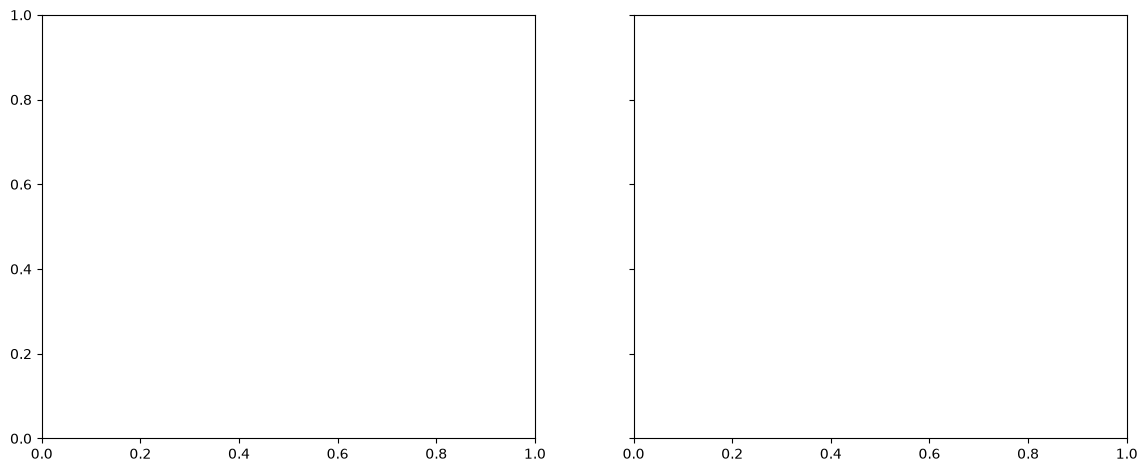

In [ ]:
# ------------------------------------------------------------
# RQ2 kernel ranking using RQ1 diagnostics
# ------------------------------------------------------------

mode_agg_nr, kernel_scores_nr = kernel_spectral_score(
    summary_nr,
    trials_df_nr,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.00,  # was 0.75
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.00,  # was 0.75
        "mean_spectral_gap": 0.5,
    },
    hard_constraints={
        "max_spurious_residual_count": 5,
    },
)

mode_agg_nr.to_csv("rot_herm_modes.csv", index=False)
kernel_scores_nr.to_csv("rot_herm_scores.csv", index=False)

rot_scores_sorted = kernel_scores_nr.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)

rot_scores_sorted.to_csv("rot_herm_ranking.csv", index=False)

# ------------------------------------------------------------
# RQ2 summary tables
# ------------------------------------------------------------

best_by_omega_method = (
    rot_scores_sorted.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)

best_by_omega_method.to_csv("rot_herm_omega_method.csv", index=False)
display(best_by_omega_method)

score_traj = best_by_omega_method[
    [
        "kind",
        "method",
        "kernel",
        "composite_score",
        "mean_spectral_gap",
        "mean_spurious_residual_count",
    ]
].copy()

score_traj.to_csv("rot_herm_trajectory.csv", index=False)
display(score_traj)


# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------

kernel_scores_nr["kvar"] = kernel_scores_nr["kernel"].map(extract_kvar)


# 5a. ranking bars by omega and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for omega in omegas:
    sub = kernel_scores_nr.loc[kernel_scores_nr["kind"].astype(str).eq(f"omega={omega}")].copy()

    sub["method"] = sub["method"].astype(str).str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank"], ascending=[True]).reset_index(drop=True)

        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=0, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=5, rotation=90
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Langevin rotation Hermite kernel ranking (omega={omega})", fontsize=12)
    fig.tight_layout()
    fig.savefig(
        f"rot_herm_ranking_{str(omega).replace('.', 'p')}.png", dpi=200, bbox_inches="tight"
    )
    plt.close(fig)

# 5b. best-score trajectory vs omega
plot_best = best_by_omega_method.copy()
plot_best["omega"] = plot_best["kind"].str.replace("omega=", "", regex=False).astype(float)
plot_best["kvar"] = plot_best["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("omega")
    ax.plot(g["omega"], g["composite_score"], marker="o", linewidth=2, label=method)

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['kvar']}",
            xy=(row["omega"], row["composite_score"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

ax.set_xlabel("Omega")
ax.set_ylabel("Best score")
ax.set_title("Best Hermite kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("rot_herm_omega_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs omega
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    sub = plot_best[plot_best["method"] == method].copy()
    sub["omega_num"] = pd.to_numeric(sub["omega"], errors="coerce")

    g = sub.sort_values(["omega_num"], ascending=[True]).reset_index(drop=True)

    x = np.arange(len(g))
    y = g["composite_score"].to_numpy()
    ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

    bars = ax.bar(x, y, color="#ffb6c1", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"ω={om}\n{k}" for om, k in zip(g["omega"], g["kvar"])],
        rotation=90,
        ha="right",
        fontsize=7,
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

    for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
        dx = -0.08 if i % 2 == 0 else 0.08
        ax.text(
            xi + dx,
            yi + ypad,
            f"#{int(rk)}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected Hermite kernel across omega", fontsize=14)
fig.tight_layout()
fig.savefig("rot_herm_omega.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved rotational Hermite outputs")


In [12]:

# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------

kernel_scores_nr["kvar"] = kernel_scores_nr["kernel"].map(extract_kvar)


# 5a. ranking bars by omega and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for omega in omegas:
    sub = kernel_scores_nr.loc[kernel_scores_nr["kind"].astype(str).eq(f"omega={omega}")].copy()

    sub["method"] = sub["method"].astype(str).str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank"], ascending=[True]).reset_index(drop=True)

        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=0, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=5, rotation=90
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Langevin rotation Hermite kernel ranking (omega={omega})", fontsize=12)
    fig.tight_layout()
    fig.savefig(
        f"rot_herm_ranking_{str(omega).replace('.', 'p')}.png", dpi=200, bbox_inches="tight"
    )
    plt.close(fig)

# 5b. best-score trajectory vs omega
plot_best = best_by_omega_method.copy()
plot_best["omega"] = plot_best["kind"].str.replace("omega=", "", regex=False).astype(float)
plot_best["kvar"] = plot_best["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("omega")
    ax.plot(g["omega"], g["composite_score"], marker="o", linewidth=2, label=method)

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['kvar']}",
            xy=(row["omega"], row["composite_score"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

ax.set_xlabel("Omega")
ax.set_ylabel("Best score")
ax.set_title("Best Hermite kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("rot_herm_omega_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs omega
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    sub = plot_best[plot_best["method"] == method].copy()
    sub["omega_num"] = pd.to_numeric(sub["omega"], errors="coerce")

    g = sub.sort_values(["omega_num"], ascending=[True]).reset_index(drop=True)

    x = np.arange(len(g))
    y = g["composite_score"].to_numpy()
    ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

    bars = ax.bar(x, y, color="#ffb6c1", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"ω={om}\n{k}" for om, k in zip(g["omega"], g["kvar"])],
        rotation=90,
        ha="right",
        fontsize=7,
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

    for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
        dx = -0.08 if i % 2 == 0 else 0.08
        ax.text(
            xi + dx,
            yi + ypad,
            f"#{int(rk)}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected Hermite kernel across omega", fontsize=14)
fig.tight_layout()
fig.savefig("rot_herm_omega.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved rotational Hermite outputs")

Saved rotational Hermite outputs


### Duffing oscillator

In [ ]:
from kooplearn.datasets import make_duffing


def simulate_duffing_dataset(
    n_steps,
    dt,
    random_state,
    omega,
    alpha=-1.0,
    beta=1.0,
    gamma_drive=0.3,
    delta=0.2,
    x0_scale=0.5,
):
    rng = np.random.default_rng(random_state)
    X0 = rng.uniform(-x0_scale, x0_scale, size=2)
    df = make_duffing(
        X0=X0,
        n_steps=n_steps,
        dt=dt,
        alpha=alpha,
        beta=beta,
        gamma=gamma_drive,
        delta=delta,
        omega=omega,
    )
    return df.reset_index(drop=True)


dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
alpha_reg = 0
M = 10
r = n_components

kvars = ["good", "bad", "ugly"]
omegas = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]  # kvar of periodic driving / non-reversibility

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

trials_records_nr = []
modes_records_nr = []

for omega in omegas:
    kind = f"omega={omega}"

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for trial in range(n_trials):
            train_seed = 10_000 + trial
            val_seed = 20_000 + trial

            data = (
                simulate_duffing_dataset(
                    n_steps=n_steps_train,
                    dt=dt,
                    random_state=train_seed,
                    omega=omega,
                )
                .iloc[::subsample][:n_train]
                .reset_index(drop=True)
            )

            data_val = (
                simulate_duffing_dataset(
                    n_steps=n_steps_val,
                    dt=dt,
                    random_state=val_seed,
                    omega=omega,
                )
                .iloc[::subsample][:n_val]
                .reset_index(drop=True)
            )

            X_val = data_val.iloc[:-1].values
            Y_val = data_val.iloc[1:].values

            for kvar in tqdm(kvars, desc=f"{method} / omega={omega}"):
                kernel = hermite_kernel(kvar, r, M)
                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    kernel=kernel,
                    alpha=alpha_reg,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat)))

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_nr.append(
                    {
                        "kernel": f"hermite({kvar})",
                        "kind": kind,
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": np.nan,
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_nr.append(
                        {
                            "kernel": f"hermite({kvar})",
                            "kind": kind,
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_duf, trials_df_duf, summary_duf, corr_df_duf, fig1_duf, fig2_duf = analyse_spectrum(
    modes_records_nr, trials_records_nr, out_prefix="duf_herm"
)


Principal Components (kDMD) / omega=0.5:   0%|          | 0/4 [00:00<?, ?it/s]


ValueError: u

In [ ]:
# ------------------------------------------------------------
# RQ2 kernel ranking using the RQ1 diagnostics
# ------------------------------------------------------------


mode_agg_duf, kernel_scores_duf = kernel_spectral_score(
    summary_duf,
    trials_df_duf,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
        "std_spectral_gap": 0.25,
    },
    hard_constraints={"max_spurious_residual_count": 5},
)

mode_agg_duf.to_csv("duf_herm_modes.csv", index=False)
kernel_scores_duf.to_csv("duf_herm_scores.csv", index=False)

duf_scores_sorted = kernel_scores_nr.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
duf_scores_sorted.to_csv("duf_herm_ranking.csv", index=False)

best_by_omega_method = (
    kernel_scores_duf.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)
best_by_omega_method.to_csv("duf_herm_omega_method.csv", index=False)

# use the robust selector from before instead of hardcoding names again
core_cols = ["kind", "method", "kernel", "composite_score"]
gap_col = next((c for c in best_by_omega_method.columns if "gap" in c and "mean" in c), None)
spur_col = next((c for c in best_by_omega_method.columns if "spur" in c and "mean" in c), None)
missing = [n for n, c in [("gap", gap_col), ("spur", spur_col)] if c is None]
if missing:
    raise ValueError(
        f"Couldn't find columns for: {missing}. Columns present: {best_by_omega_method.columns.tolist()}"
    )

score_traj = (
    best_by_omega_method[core_cols + [gap_col, spur_col]]
    .rename(columns={gap_col: "spectral_gap_mean", spur_col: "spurious_residual_count_mean"})
    .copy()
)
score_traj.to_csv("duf_herm_trajectory.csv", index=False)


# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------
kernel_scores_duf["kvar"] = kernel_scores_duf["kernel"].map(extract_kvar)


# 5a. ranking bars by omega and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for omega in omegas:
    sub = kernel_scores_duf.loc[kernel_scores_duf["kind"].astype(str).eq(f"omega={omega}")].copy()

    sub["method"] = sub["method"].astype(str).str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank"], ascending=[True, True]).reset_index(drop=True)

        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=0, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=5, rotation=90
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Duffing oscillator Hermite kernel ranking (omega={omega})", fontsize=12)
    fig.tight_layout()
    fig.savefig(
        f"duf_herm_ranking_{str(omega).replace('.', 'p')}.png", dpi=200, bbox_inches="tight"
    )
    plt.close(fig)

# 5b. best-score trajectory vs omega
plot_best = best_by_omega_method.copy()
plot_best["omega"] = plot_best["kind"].str.replace("omega=", "", regex=False).astype(float)
plot_best["kvar"] = plot_best["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("omega")
    ax.plot(g["omega"], g["composite_score"], marker="o", linewidth=2, label=method)

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['kvar']}",
            xy=(row["omega"], row["composite_score"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

ax.set_xlabel("Omega")
ax.set_ylabel("Best score")
ax.set_title("Best Hermite kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("rot_herm_omega_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs omega
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    sub = plot_best[plot_best["method"] == method].copy()
    sub["omega_num"] = pd.to_numeric(sub["omega"], errors="coerce")

    g = sub.sort_values(["omega_num"], ascending=[True, True]).reset_index(drop=True)

    x = np.arange(len(g))
    y = g["composite_score"].to_numpy()
    ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

    bars = ax.bar(x, y, color="#ffb6c1", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"ω={om}\n{k}" for om, k in zip(g["omega"], g["kvar"])],
        rotation=90,
        ha="right",
        fontsize=7,
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

    for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
        dx = -0.08 if i % 2 == 0 else 0.08
        ax.text(
            xi + dx,
            yi + ypad,
            f"#{int(rk)}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected Hermite kernel across omega", fontsize=14)
fig.tight_layout()
fig.savefig("duf_herm_omega.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved RQ2 outputs")


### Logistic map

In [ ]:
from kooplearn.datasets import compute_logistic_map_eig, make_logistic_map

# Defining logistic map "hyperparameters"
X0_bounds = (0.05, 0.95)  # randomized scalar starts in (0, 1), away from edge cases
M_log = 20

# Defining the number of samples for each data split
n_train = 2000
n_val = 500
dt = 1
subsample = 20
n_trials = 10
n_components = 5
alpha_reg = 0
M = 10
k_r = n_components = 5

kvars = ["good", "bad", "ugly"]
rs = [
    0.0,
    0.5,
    1.2,
    2.5,
    3.2,
    4.0,
]  # growth-rate parameter sweep

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample


def simulate_logistic_map(
    X0_bounds,
    n_steps,
    r,
    M_log,
    dt,
    random_state,
):
    rng = np.random.default_rng(random_state)

    # Randomized scalar initial condition in (0, 1)
    x0 = float(rng.uniform(*X0_bounds))

    df = make_logistic_map(
        X0=x0,
        n_steps=n_steps,
        r=r,
        M=M_log,
        dt=dt,
        random_state=random_state,
    )

    # Keep the return type aligned with the rest of your notebook workflow
    return df.reset_index(drop=True)


vals_ref = compute_logistic_map_eig(M=M)

trials_records_log = []
modes_records_log = []

for r in rs:
    kind = f"r={r}"

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for trial in range(n_trials):
            train_seed = 10_000 + trial
            val_seed = 20_000 + trial

            data = (
                simulate_logistic_map(
                    X0_bounds=X0_bounds,
                    n_steps=n_steps_train,
                    r=r,
                    M=M,
                    dt=dt,
                    random_state=train_seed,
                )
                .iloc[::subsample][:n_train]
                .reset_index(drop=True)
            )

            data_val = (
                simulate_logistic_map(
                    X0_bounds=X0_bounds,
                    n_steps=n_steps_val,
                    r=r,
                    M_log = M_log,
                    dt=dt,
                    random_state=val_seed,
                )
                .iloc[::subsample][:n_val]
                .reset_index(drop=True)
            )

            X_val = data_val.iloc[:-1].values
            Y_val = data_val.iloc[1:].values
            for kvar in tqdm(kvars, desc=f"{method} / r={r}"):
                kernel = hermite_kernel(kvar, k_r, M)

                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    kernel=kernel,
                    alpha=alpha_reg,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat = vals_hat[sort_perm]
                funcs_hat = funcs_hat[:, sort_perm]

                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)
                gap = spectral_gap(vals_hat)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat)))

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat,
                    psi_X_val,
                    psi_Y_val,
                    delta=0.1,
                    relative=True,
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_log.append(
                    {
                        "kernel": f"hermite({kvar})",
                        "kind": kind,
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_log.append(
                        {
                            "kernel": f"hermite({kvar})",
                            "kind": kind,
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_log, trials_df_log, summary_log, corr_df_log, fig1_log, fig2_log = analyse_spectrum(
    modes_records_log,
    trials_records_log,
    out_prefix="log_herm",
)


TypeError: simulate_logistic_map() got an unexpected keyword argument 'M'

In [ ]:
# ------------------------------------------------------------
# RQ2 kernel ranking using the RQ1 diagnostics
# ------------------------------------------------------------

mode_agg_log, kernel_scores_log = kernel_spectral_score(
    summary_log,
    trials_df_log,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.00,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.00,
        "mean_spectral_gap": 0.5,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)

mode_agg_log.to_csv("log_herm_modes.csv", index=False)
kernel_scores_log.to_csv("log_herm_scores.csv", index=False)

log_scores_sorted = kernel_scores_log.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
log_scores_sorted.to_csv("log_herm_ranking.csv", index=False)

best_by_r_method = (
    kernel_scores_log.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)
best_by_r_method.to_csv("log_herm_r_method.csv", index=False)

# use robust selector from before instead of hardcoding names
core_cols = ["kind", "method", "kernel", "composite_score"]
gap_col = next((c for c in best_by_r_method.columns if "gap" in c and "mean" in c), None)
spur_col = next((c for c in best_by_r_method.columns if "spur" in c and "mean" in c), None)
missing = [n for n, c in [("gap", gap_col), ("spur", spur_col)] if c is None]
if missing:
    raise ValueError(
        f"Couldn't find columns for: {missing}. Columns present: {best_by_r_method.columns.tolist()}"
    )

score_traj = (
    best_by_r_method[core_cols + [gap_col, spur_col]]
    .rename(columns={gap_col: "spectral_gap_mean", spur_col: "spurious_residual_count_mean"})
    .copy()
)
score_traj.to_csv("log_herm_trajectory.csv", index=False)


# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------

kernel_scores_log["kvar"] = kernel_scores_log["kernel"].map(extract_kvar)

# 5a. ranking bars by r and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for r in rs:
    sub = kernel_scores_log.loc[kernel_scores_log["kind"].astype(str).eq(f"r={r}")].copy()
    sub["method"] = sub["method"].astype(str).str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    methods = ["Principal Components (kDMD)", "Reduced Rank"]

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank"], ascending=[True, True]).reset_index(drop=True)
        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=90, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx,
                yi + offset,
                f"#{int(rk)}",
                ha="center",
                va=va,
                fontsize=7,
                rotation=90,
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Logistic map Hermite kernel ranking (r={r})", fontsize=14)
    fig.tight_layout()
    fig.savefig(f"log_herm_ranking_{str(r).replace('.', 'p')}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# 5b. best-score trajectory vs r
plot_best = best_by_r_method.copy()
plot_best["r"] = plot_best["kind"].str.replace("r=", "", regex=False).astype(float)
plot_best["kvar"] = plot_best["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("r")
    ax.plot(g["r"], g["composite_score"], marker="o", linewidth=2, label=method)

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['kvar']}",
            (row["r"], row["composite_score"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set_xlabel("r")
ax.set_ylabel("Best score")
ax.set_title("Best Hermite kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("log_herm_r_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs r
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    sub = plot_best[plot_best["method"] == method].copy()

    g = sub.sort_values(["r"], ascending=[True, True]).reset_index(drop=True)

    x = np.arange(len(g))
    y = g["composite_score"].to_numpy()
    ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

    bars = ax.bar(x, y, color="#ffb6c1", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"r={r}\n{k}" for r, k in zip(g["r"], g["kvar"])],
        rotation=90,
        ha="right",
        fontsize=7,
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

    for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
        dx = -0.08 if i % 2 == 0 else 0.08
        ax.text(
            xi + dx,
            yi + ypad,
            f"#{int(rk)}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=7,
        )

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected Hermite kernel across r", fontsize=14)
fig.tight_layout()
fig.savefig("log_herm_r.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved Hermite logistic outputs")


## RQ3

### `kooplearn` native linear system

In [ ]:
# ------------------------------------------------------------
# RQ3: linear benchmark
# ------------------------------------------------------------

from kooplearn.datasets import make_linear_system


def simulate_linear_dataset(n_steps, A_continuous, dt, beta, random_state, x0=None):
    """
    Wrapper around kooplearn.datasets.make_linear_system, reproducing the exact
    first-order Euler-Maruyama discretisation of
        dX = A_continuous X dt + sqrt(2/beta) dW
    generated via kooplearn's own routine
        x_{t+1} = A x_t + xi_t, isotropic Gaussian xi_t instead.
    """
    d = A_continuous.shape[0]
    A_discrete = np.eye(d) + dt * A_continuous
    noise_std = np.sqrt(2.0 * dt / beta)
    if x0 is None:
        x0 = np.zeros(d)
    df = make_linear_system(
        X0=x0,
        A=A_discrete,
        n_steps=n_steps,
        noise=noise_std,
        random_state=random_state,
    )
    return df.reset_index(drop=True)


def compute_linear_eigs(A, lag, num_components=5):
    """
    Simple reference for leading Koopman eigenvalues of linear observables:
    1, eig(exp(A*lag)), and selected quadratic products.
    """
    M = expm(A * lag)
    lam = np.linalg.eigvals(M)
    ref = [1.0 + 0j]

    for z in lam:
        ref.append(complex(z))

    for i in range(len(lam)):
        for j in range(i, len(lam)):
            ref.append(complex(lam[i] * lam[j]))

    ref = np.array(ref[:num_components], dtype=complex)
    return ref


# Parameters
dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
beta = 1.0

# Define reversible and non-reversible linear cases
A_cases = {
    "rev": np.array([[-1.0, 0.0], [0.0, -2.0]], dtype=float),
    "rot": np.array([[-1.0, 2.0], [-2.0, -1.5]], dtype=float),
}


kvars = ["good", "bad", "ugly"]
M = 10
r = n_components

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample
lag = dt * subsample

trials_records_linear = []
modes_records_linear = []

for dir in A_cases:
    kind = f"A={dir}"

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for trial in range(n_trials):
            A = A_cases[dir]
            vals_ref = compute_linear_eigs(A, lag=lag, num_components=n_components)

            data = simulate_linear_dataset(
                n_steps=n_steps_train,
                A_continuous=A,
                dt=dt,
                beta=beta,
                random_state=1000 + trial,
                x0=np.array([0.0, 0.0]),
            ).iloc[::subsample][:n_train]

            data_val = simulate_linear_dataset(
                n_steps=n_steps_val,
                A_continuous=A,
                dt=dt,
                beta=beta,
                random_state=9000 + trial,
                x0=np.array([0.0, 0.0]),
            ).iloc[::subsample][:n_val]

            X_val = data_val.iloc[:-1].values
            Y_val = data_val.iloc[1:].values

            for kvar in tqdm(kvars, desc=f"{method} / A={dir}"):
                kernel = hermite_kernel(kvar, r, M)
                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    kernel=kernel,
                    alpha=0,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)
                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.1)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
                    "eig() ordering changed between calls"
                )

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_linear.append(
                    {
                        "kind": kind,
                        "kernel": f"hermite({kvar})",
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": fit_rank,
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_linear.append(
                        {
                            "kind": kind,
                            "kernel": f"hermite({kvar})",
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_linear, trials_df_linear, summary_linear, corr_df_linear, fig1_linear, fig2_linear = (
    analyse_spectrum(modes_records_linear, trials_records_linear, out_prefix="lin_herm")
)

mode_agg_linear, kernel_scores_linear = kernel_spectral_score(
    summary_linear,
    trials_df_linear,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)
mode_agg_linear.to_csv("lin_herm_modes.csv", index=False)
kernel_scores_linear.to_csv("lin_herm_scores.csv", index=False)

linear_scores_sorted = kernel_scores_linear.sort_values(
    ["kind", "method", "rank", "kernel"]
).reset_index(drop=True)

linear_scores_sorted.to_csv("lin_herm_ranking.csv", index=False)

plot_kernel_rankings(kernel_scores_linear, trials_df_linear, facet_col="kind", prefix="lin_herm")

kernel_scores_linear["kvar"] = kernel_scores_linear["kernel"].map(extract_kvar)

# Ranking bars by A and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for dir in A_cases:
    sub = kernel_scores_linear.loc[kernel_scores_linear["kind"].astype(str).eq(f"A={dir}")].copy()
    sub["method"] = sub["method"].astype(str).str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    methods = ["Principal Components (kDMD)", "Reduced Rank"]

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank"], ascending=[True]).reset_index(drop=True)
        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.03 * max(1.0, np.nanmax(np.abs(y)))

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=90, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx,
                yi + offset,
                f"#{int(rk)}",
                ha="center",
                va=va,
                fontsize=7,
                rotation=90,
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Linear system polynomial kernel ranking (A={dir})", fontsize=14)
    fig.tight_layout()
    fig.savefig(f"lin_herm_ranking_{dir}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)


print("Saved Hermite linear outputs")


### Hamiltonian harmonic oscillator
State:

$x=(q,p)$ (position, momentum)

Dynamics:

$\dot{q}=p$

$\dot{p}=−q$

i.e. the standard unit‑frequency harmonic oscillator, which is Hamiltonian and time‑reversible with involution $π(q,p)=(q,−p)$.

Analytic flow:

$q(t)=q_0 \cos{t}+p_0 \sin{t}$

$p(t)=−q_0\sin{t}+p_0 \cos{t}$

In [ ]:
# Parameters
dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

kvars = ["good", "bad", "ugly"]
M = 10
r = n_components

# Harmonic oscillator parameters
n_initial = 256
t_max = 50
n_steps = n_steps_train + n_steps_val
init_radius = 1.0
omega = 1.0  # angular frequency

K_decay = 4  # observe ~4 decay times for damped regimes — enough to see decay, not enough to vanish/blow up
K_periods = 10  # for damping=0 (no decay timescale exists), observe ~10 oscillation periods instead


def t_max_for_damping(damping, omega):
    if damping == 0.0:
        period = 2 * np.pi / omega
        return K_periods * period
    tau_decay = 1.0 / damping
    return K_decay * tau_decay


def harmonic_oscillator_flow(q0, p0, t, omega=1.0, damping=0.0):
    """
    Analytic flow for the (possibly damped) harmonic oscillator:
        dq/dt = p
        dp/dt = -omega^2 * q - 2*damping * p
    Handles all three regimes: under-damped (0<=damping<omega),
    critically damped (damping==omega), over-damped (damping>omega).
    """
    t = np.asarray(t, dtype=float)

    if damping == 0.0:
        q_t = q0 * np.cos(omega * t) + (p0 / omega) * np.sin(omega * t)
        p_t = -q0 * omega * np.sin(omega * t) + p0 * np.cos(omega * t)
        return q_t, p_t

    disc = omega**2 - damping**2

    if disc > 0.0:
        # Under-damped — your original formula, unchanged
        omega_d = np.sqrt(disc)
        A = q0
        B = (p0 + damping * q0) / omega_d
        exp_term = np.exp(-damping * t)
        cos_term = np.cos(omega_d * t)
        sin_term = np.sin(omega_d * t)
        q_t = exp_term * (A * cos_term + B * sin_term)
        dqdt_inner = -A * omega_d * sin_term + B * omega_d * cos_term
        p_t = exp_term * (dqdt_inner - damping * (A * cos_term + B * sin_term))
        return q_t, p_t

    elif disc == 0.0:
        # Critically damped: q(t) = (A + B t) e^{-damping t}
        A = q0
        B = p0 + damping * q0
        exp_term = np.exp(-damping * t)
        q_t = exp_term * (A + B * t)
        p_t = exp_term * (B - damping * (A + B * t))
        return q_t, p_t

    else:
        # Over-damped: q(t) = C1 e^{r1 t} + C2 e^{r2 t}, real distinct roots
        omega_o = np.sqrt(-disc)  # = sqrt(damping^2 - omega^2)
        r1 = -damping + omega_o
        r2 = -damping - omega_o
        C1 = (p0 - r2 * q0) / (r1 - r2)
        C2 = q0 - C1
        q_t = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)
        p_t = C1 * r1 * np.exp(r1 * t) + C2 * r2 * np.exp(r2 * t)
        return q_t, p_t


def generate_ho(
    n_initial=n_initial,
    t_max=t_max,
    n_steps=n_steps,
    init_radius=init_radius,
    seed=10_000,
    omega=1.0,
    damping=0.0,
):
    rng = np.random.default_rng(seed)

    # Sample initial conditions roughly uniformly in a disk in (q,p)
    angles = rng.uniform(0.0, 2.0 * np.pi, size=n_initial)
    radii = init_radius * np.sqrt(rng.uniform(0.0, 1.0, size=n_initial))
    q0 = radii * np.cos(angles)
    p0 = radii * np.sin(angles)

    # Time grid
    t_grid = np.linspace(0.0, t_max, n_steps)

    # Forward trajectories: shape (n_initial, n_steps, 2)
    Q = np.empty((n_initial, n_steps), dtype=float)
    P = np.empty((n_initial, n_steps), dtype=float)
    for i in range(n_initial):
        q_t, p_t = harmonic_oscillator_flow(q0[i], p0[i], t_grid, omega=omega, damping=damping)
        Q[i] = q_t
        P[i] = p_t

    X_forward = np.stack([Q, P], axis=-1)  # (n_initial, n_steps, 2)

    # Time-reversed trajectories under pi(q,p) = (q,-p):
    # start from pi(q_T, p_T) and run backwards in t
    # Exact reversal only holds for gamma=0; for gamma>0 this is a diagnostic, not a symmetry.
    Q_rev = np.empty_like(Q)
    P_rev = np.empty_like(P)
    for i in range(n_initial):
        q_T = Q[i, -1]
        p_T = P[i, -1]
        # apply time-reversal involution pi
        q0_rev, p0_rev = q_T, -p_T
        q_rev_t, p_rev_t = harmonic_oscillator_flow(q0_rev, p0_rev, -t_grid, omega, damping)
        Q_rev[i] = q_rev_t
        P_rev[i] = p_rev_t

    X_reverse = np.stack([Q_rev, P_rev], axis=-1)

    return {
        "t_grid": t_grid,
        "q0": q0,
        "p0": p0,
        "omega": omega,
        "damping": damping,
        "X_forward": X_forward,  # training data for forward Koopman
        "X_reverse": X_reverse,  # explicit time-reversed trajectories
    }


def compute_linear_eigs(A, lag, num_components=5):
    """
    Simple reference for leading Koopman eigenvalues of linear observables:
    1, eig(exp(A*lag)), and selected quadratic products.
    """
    M = expm(A * lag)
    lam = np.linalg.eigvals(M)
    ref = [1.0 + 0j]

    for z in lam:
        ref.append(complex(z))

    for i in range(len(lam)):
        for j in range(i, len(lam)):
            ref.append(complex(lam[i] * lam[j]))

    ref = np.array(ref[:num_components], dtype=complex)
    return ref


trials_records_ho = []
modes_records_ho = []

damping_regimes = [0.0, 0.1 * omega, 0.3 * omega, 0.5 * omega, omega, 1.5 * omega]

for damping in damping_regimes:
    kind = f"damping={damping}"

    # Continuous-time matrix for this damped HO:
    # dq/dt = p
    # dp/dt = -omega^2 q - 2*damping p

    t_max_regime = t_max_for_damping(damping, omega)
    dt_grid = t_max_regime / (n_steps - 1)  # actual physical spacing this regime will use
    lag = dt_grid * subsample

    # sample and printy per-regime magnitude/scale diagnostics
    # before expensive kernel-fitting loop
    sample = generate_ho(
        n_initial=1, t_max=t_max_regime, n_steps=n_steps, seed=0, omega=omega, damping=damping
    )
    fwd_range = np.abs(sample["X_forward"]).max()
    rev_range = np.abs(sample["X_reverse"]).max()
    print(
        f"damping={damping:.2f}  t_max={t_max_regime:.2f}  fwd max={fwd_range:.3g}  rev max={rev_range:.3g}"
    )

    A_ho = np.array([[0.0, 1.0], [-(omega**2), -2.0 * damping]], dtype=float)
    vals_ref = compute_linear_eigs(A_ho, lag=lag, num_components=n_components)

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for trial in range(n_trials):
            seed = 10_000 + trial
            data = generate_ho(
                n_initial=1,
                t_max=t_max_regime,
                n_steps=n_steps,
                init_radius=init_radius,
                seed=seed,
                omega=omega,
                damping=damping,
            )

            # Extract the single trajectory (shape (n_steps, 2))
            X_fwd = data["X_forward"][0]  # (n_steps, 2)
            X_rev = data["X_reverse"][0]  # (n_steps, 2)

            # Subsample and split into train/val
            X_fwd = X_fwd[::subsample]
            X_rev = X_rev[::subsample]

            X_train = X_fwd[:n_train]
            data_val = X_rev[:n_val]

            # Build DataFrames for KernelRidge
            df_train = pd.DataFrame(X_train, columns=["q", "p"])
            df_val = pd.DataFrame(data_val, columns=["q", "p"])

            X_val = df_val.iloc[:-1].values
            Y_val = df_val.iloc[1:].values
            for kvar in tqdm(kvars, desc=f"{method} / damping={damping}"):
                kernel = hermite_kernel(kvar, r, M)
                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    kernel=kernel,
                    alpha=0,
                    random_state=trial,
                )
                model.fit(df_train)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)
                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.1)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
                    "eig() ordering changed between calls"
                )

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_ho.append(
                    {
                        "kind": kind,
                        "kernel": f"hermite({kvar})",
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": fit_rank,
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_ho.append(
                        {
                            "kind": kind,
                            "kernel": f"hermite({kvar})",
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_ho, trials_df_ho, summary_ho, corr_df_ho, fig1_ho, fig2_ho = analyse_spectrum(
    modes_records_ho, trials_records_ho, out_prefix="ho_herm"
)

mode_agg_ho, kernel_scores_ho = kernel_spectral_score(
    summary_ho,
    trials_df_ho,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)

mode_agg_ho.to_csv("ho_herm_modes.csv", index=False)
kernel_scores_ho.to_csv("ho_herm_scores.csv", index=False)

ho_scores_sorted = kernel_scores_ho.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
ho_scores_sorted.to_csv("ho_herm_ranking.csv", index=False)


kernel_scores_ho["kvar"] = kernel_scores_ho["kernel"].map(extract_kvar)

# 5a. ranking bars by omega and method
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for damping in damping_regimes:
    sub = kernel_scores_ho.loc[kernel_scores_ho["kind"].astype(str).eq(f"damping={damping}")].copy()

    sub["method"] = sub["method"].astype(str).str.strip()
    sub["rank_num"] = pd.to_numeric(sub["rank"], errors="coerce")
    sub["score_num"] = pd.to_numeric(sub["composite_score"], errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax, method in zip(axes, methods):
        g = sub.loc[sub["method"].eq(method)].copy()
        g = g.sort_values(["rank_num"], ascending=[True]).reset_index(drop=True)

        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()
        ypad = 0.05

        ax.bar(x, y, color="#D667A0", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kvar"], rotation=90, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Hermite type")
        ax.grid(axis="y", alpha=0.25)

        for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
            va = "bottom" if yi >= 0 else "top"
            offset = ypad if yi >= 0 else -ypad
            dx = -0.10 if i % 2 == 0 else 0.10
            ax.text(
                xi + dx,
                yi + offset,
                f"#{int(rk)}",
                ha="center",
                va=va,
                fontsize=7,
                rotation=90,
            )

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Harmonic oscillation Hermite kernel ranking (damping={damping})", fontsize=14)
    fig.tight_layout()
    fig.savefig(
        f"ho_herm_ranking_{str(damping).replace('.', 'p')}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(fig)

# 5b. best-score trajectory vs damping
best_by_damping_method = (
    kernel_scores_ho.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)
best_by_damping_method.to_csv("ho_herm_damp_method.csv", index=False)

plot_best = best_by_damping_method.copy()
plot_best["damping"] = plot_best["kind"].str.replace("damping=", "", regex=False).astype(float)
plot_best["kvar"] = plot_best["kernel"].map(extract_kvar)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("damping")
    ax.plot(g["damping"], g["composite_score"], marker="o", linewidth=2, label=method)

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['kvar']}",
            (row["damping"], row["composite_score"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=7,
        )

ax.set_xlabel("Damping")
ax.set_ylabel("Best score")
ax.set_title("Best Hermite kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("ho_herm_damping_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs damping
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    sub = plot_best[plot_best["method"] == method].copy()
    sub["damping_num"] = pd.to_numeric(sub["damping"], errors="coerce")

    g = sub.sort_values(["damping_num"], ascending=[True]).reset_index(drop=True)

    x = np.arange(len(g))
    y = g["composite_score"].to_numpy()
    ypad = 0.05
    bars = ax.bar(x, y, color="#ffb6c1", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"d.={d}\n{k}" for d, k in zip(g["damping"], g["kvar"])],
        rotation=90,
        ha="right",
        fontsize=7,
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

    for i, (xi, yi, rk) in enumerate(zip(x, y, g["rank"])):
        dx = -0.08 if i % 2 == 0 else 0.08
        ax.text(
            xi + dx,
            yi + ypad,
            f"#{int(rk)}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=7,
        )

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected Hermite kernel across damping regimes", fontsize=14)
fig.tight_layout()
fig.savefig("ho_herm_damping.png", dpi=200, bbox_inches="tight")
plt.close(fig)


print("Saved Hermite HO outputs")


damping=0.00  t_max=62.83  fwd max=0.519  rev max=0.519


Principal Components (kDMD) / damping=0.0:  67%|██████▋   | 2/3 [03:23<01:40, 100.44s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 4 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 1.884e-14.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Principal Components (kDMD) / damping=0.0:   0%|          | 0/3 [00:00<?, ?it/s]